In [1]:
import numpy as np
import matplotlib.pyplot as plt

from helpers.geometry_map import make_geometry_map, build_dist_tree_from_map
from helpers.data_transforms import load_in_data

from tqdm import tqdm
from helpers.material_map import apply_material_map_hybrid, build_masked_datasets
from helpers.flow import build_z_lookup, snap_z_to_detector


In [2]:
geo_map_path = "/pscratch/sd/r/rmastand/muon_collider/geometry_map.txt"

# make_geometry_map(
#     df,
#     collections,
#     geo_map_path,
#     num_events_per_col=1_000_000,
    
# )

In [3]:
tree_map, cellid_layer_map = build_dist_tree_from_map(geo_map_path)

Loaded geometry map with 6000000 hits across 6 collections


In [4]:
BIN_BOUND = 5
NUM_BINS = 60
NUM_FEATURES = 5
NUM_BDTS = 10

collections = [
    "InnerTrackerBarrelCollection",
   "InnerTrackerEndcapCollection",
    "OuterTrackerBarrelCollection",     
    "OuterTrackerEndcapCollection",  
   "VertexBarrelCollection",   
  "VertexEndcapCollection",
]


feature_order_endcap = [0,4,1,2,3,6,7,8,9]
feature_indices_dict_endcap = {
    "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6,
    "sensor":8
}

feature_order_barrel =[0,4,1,2,3,6,7,8,9]
feature_indices_dict_barrel = {
   "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6
}

feature_order_dict = {
     "InnerTrackerBarrelCollection":feature_order_barrel,
    "InnerTrackerEndcapCollection":feature_order_endcap,
    "OuterTrackerBarrelCollection":feature_order_barrel,
    "OuterTrackerEndcapCollection":feature_order_endcap,  
    "VertexBarrelCollection":feature_order_barrel,
    "VertexEndcapCollection":feature_order_endcap,

}


feature_indices_dict = {
     "InnerTrackerBarrelCollection":feature_indices_dict_barrel,
    "InnerTrackerEndcapCollection":feature_indices_dict_endcap,
    "OuterTrackerBarrelCollection":feature_indices_dict_barrel,
    "OuterTrackerEndcapCollection":feature_indices_dict_endcap,  
    "VertexBarrelCollection":feature_indices_dict_barrel,
    "VertexEndcapCollection":feature_indices_dict_endcap,

}



ZUKO_ID = "NCSF"
NAME = "cond4"
NUM_COND_INPUTS = 4
SEED = 8



FEATURES = "rphi"
working_dir = "/pscratch/sd/r/rmastand/muon_collider"
log_vars = []



In [5]:
# load in samples

all_data_dir, all_samples_dir = {}, {}


for col_name in collections:

    small_id = ''.join([c for c in col_name if c.isupper()])
    X, feature_labels = load_in_data([col_name], FEATURES, working_dir, 1, NUM_COND_INPUTS, feature_order_dict[col_name])
    all_data_dir[col_name] = X
    all_samples_dir[col_name] = np.load(f"tabddpm_{small_id}_samples.npy")
    # all_samples_dir[col_name] = np.load(f"{working_dir}/zuko_outputs/{ZUKO_ID}/{small_id}_{NAME}/flow_samples.npy")


    # if "Endcap" in col_name:
    #     plt.figure()
    
    #     z_idx = feature_indices_dict[col_name]["z"]
    #     side_idx = feature_indices_dict[col_name]["side"]
    #     layer_idx = feature_indices_dict[col_name]["layer"]
    #     sensor_idx = feature_indices_dict[col_name]["sensor"]
    
    #     # original samples
    #     z_samples = all_samples_dir[col_name][:, z_idx]
    #     sides = all_samples_dir[col_name][:, side_idx]
    #     layers = all_samples_dir[col_name][:, layer_idx]
    #     sensors = all_samples_dir[col_name][:, sensor_idx]
    
    
        
    #     z_lookup = build_z_lookup(
    #         all_data_dir[col_name],
    #         feature_indices_dict[col_name]["side"],
    #         feature_indices_dict[col_name]["layer"],
    #         feature_indices_dict[col_name]["sensor"],
    #         feature_indices_dict[col_name]["z"],
    #     )
    #     # # snap z to detector geometry
    #     z_samples_snapped = snap_z_to_detector(
    #         z_samples, sides, layers, sensors, z_lookup
        
    #     )
    #     all_samples_dir[col_name][:,feature_indices_dict[col_name]["z"]] = z_samples_snapped
    #     all_samples_dir[col_name][:,feature_indices_dict[col_name]["side"]] = np.array(sides)
    
    #     # plot truth vs snapped samples
    #     plt.hist(
    #         all_data_dir[col_name][:, z_idx],
    #         bins=np.linspace(-2000, 2000, 1000),
    #         histtype="step",
    #         label="truth"
    #     )
    
    #     plt.hist(
    #         z_samples_snapped,
    #         bins=np.linspace(-2000, 2000, 1000),
    #         histtype="step",
    #         label="flow (snapped)"
    #     )
    
    #     plt.yscale("log")
    #     plt.legend()
    #     plt.show()
   

InnerTrackerBarrelCollection
(3926196, 9) (3926196, 9)


/tmp/ipykernel_565102/85026937.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[-1].legend()


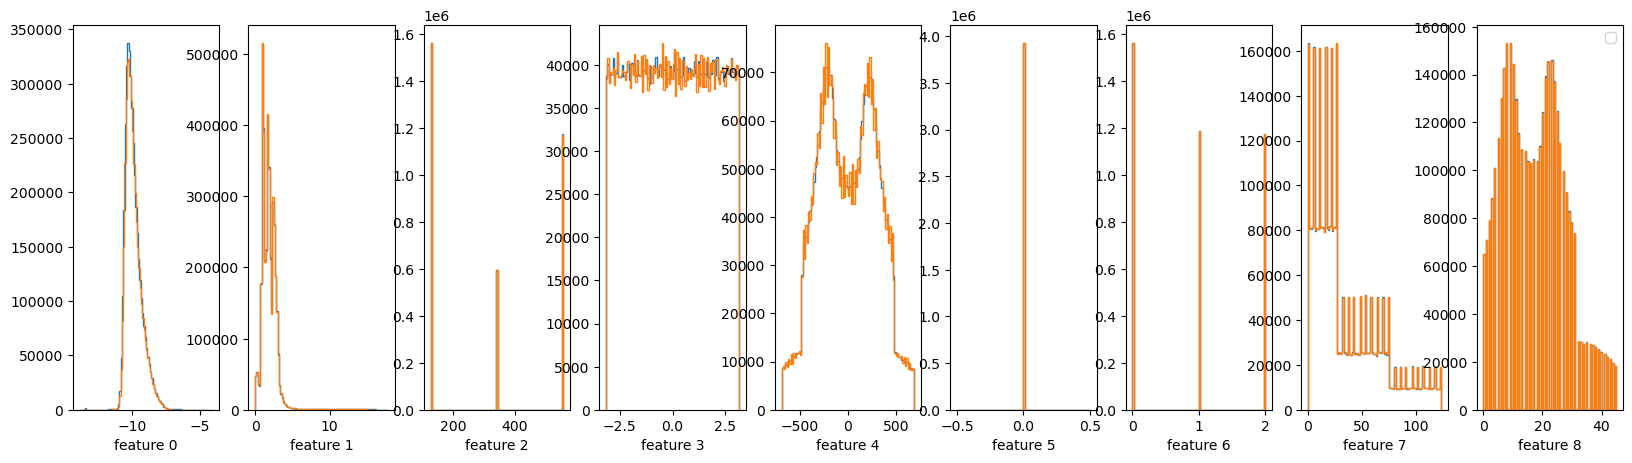

InnerTrackerEndcapCollection
(1614679, 9) (1614679, 9)


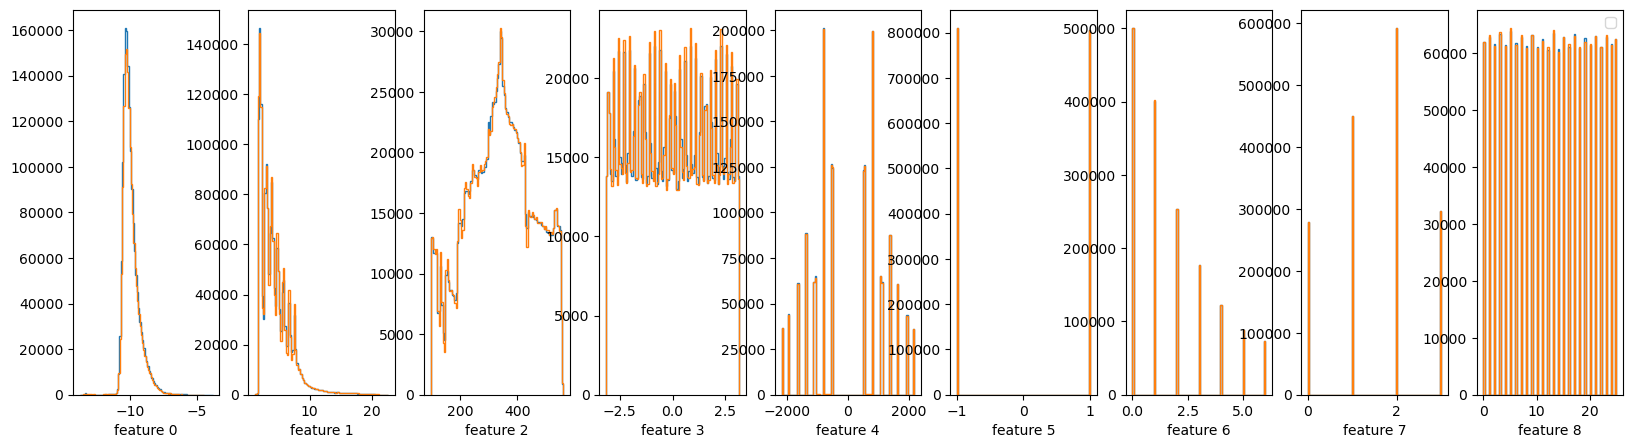

OuterTrackerBarrelCollection
(3280678, 9) (3280678, 9)


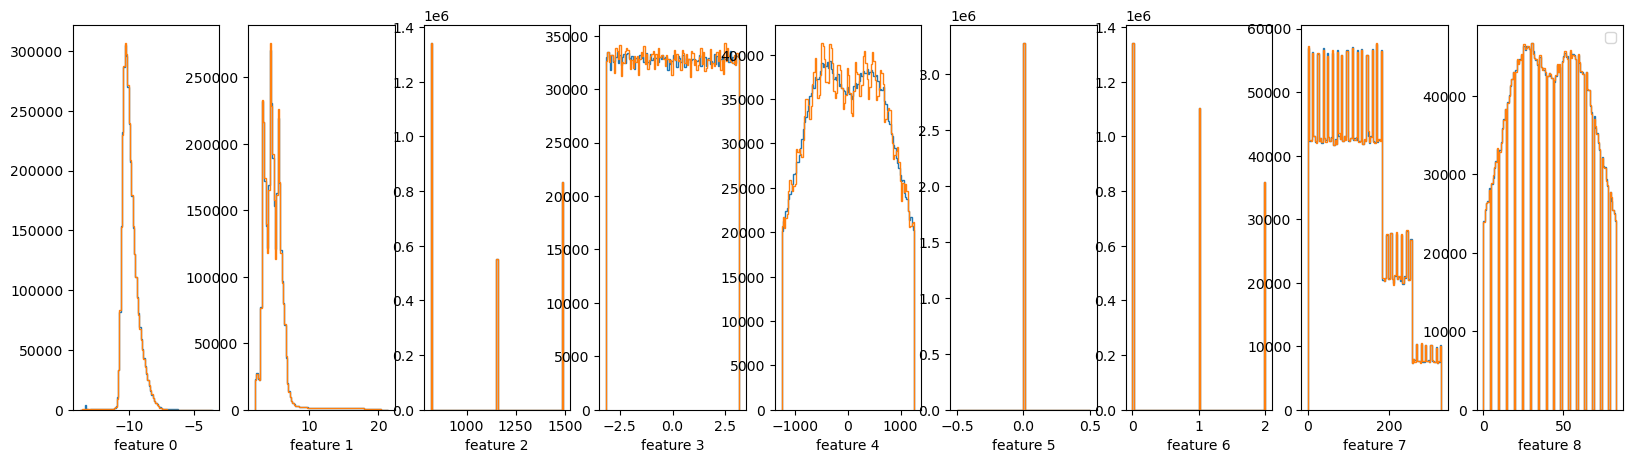

OuterTrackerEndcapCollection
(1465825, 9) (1465825, 9)


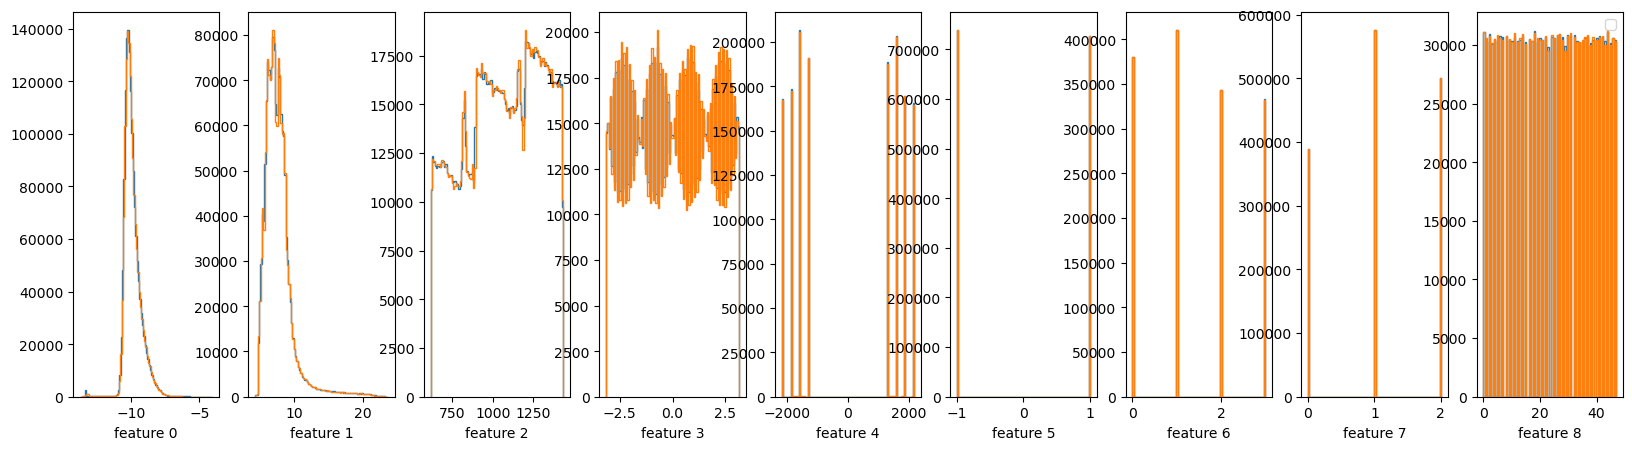

VertexBarrelCollection
(2129166, 9) (2129166, 9)


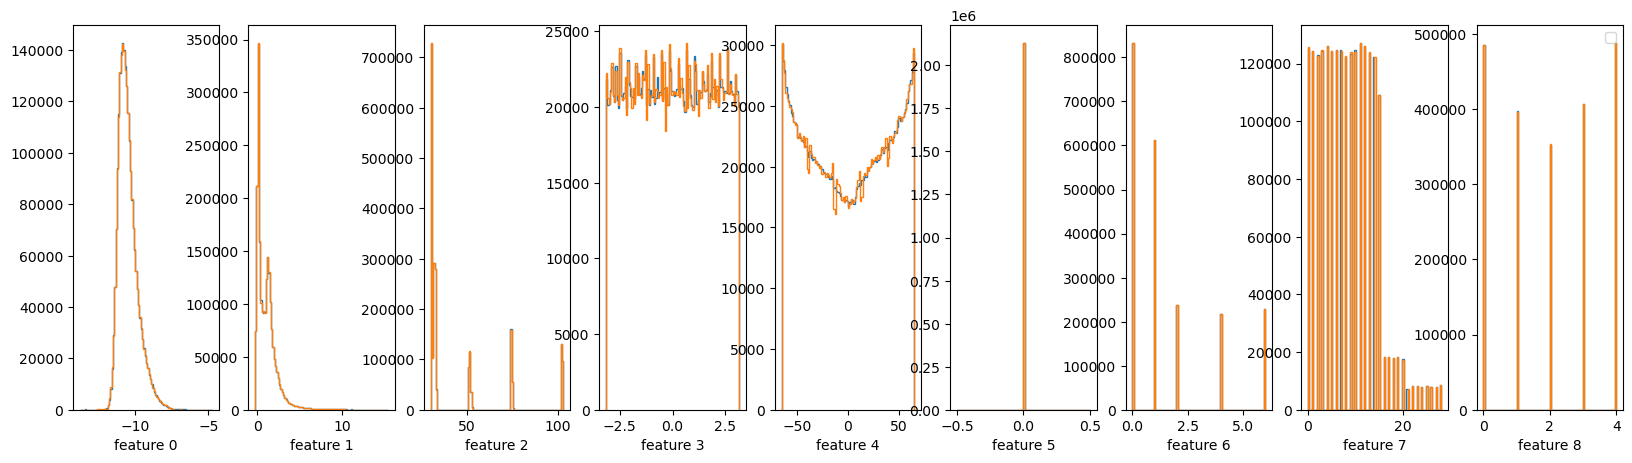

VertexEndcapCollection
(4096371, 9) (4096371, 9)


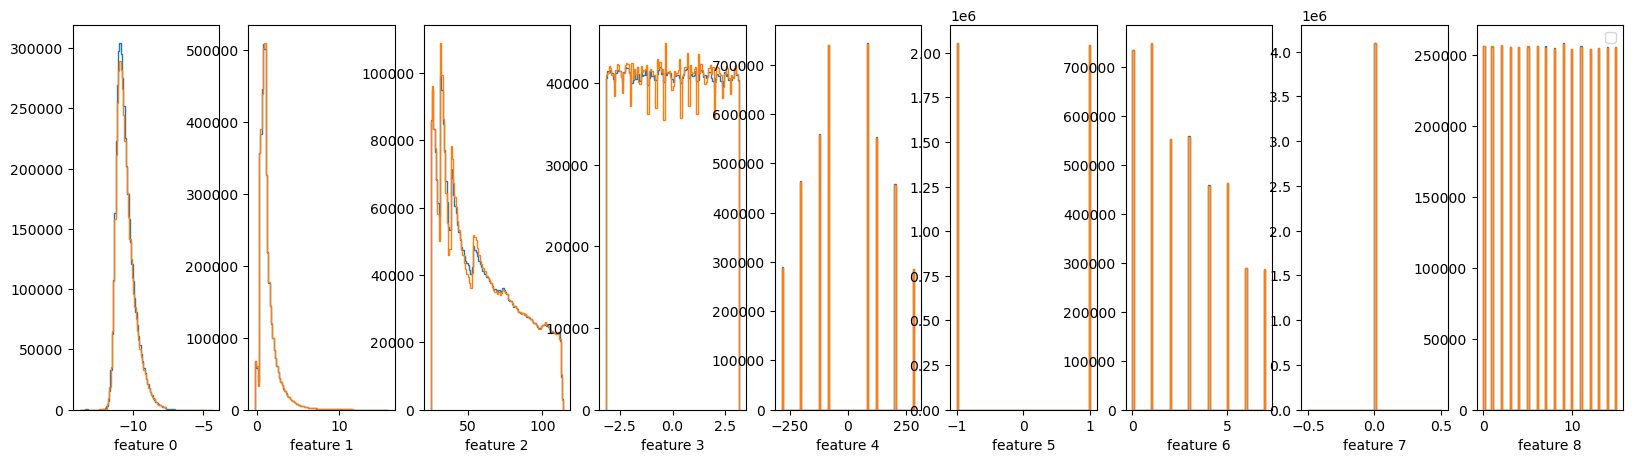

In [6]:
for col_name in collections:
    print(col_name)
    print(all_data_dir[col_name].shape, all_samples_dir[col_name].shape)

    fig, ax = plt.subplots(1, 9, figsize = (20, 5))
    for i in range(9):
        ax[i].hist(all_data_dir[col_name][:,i], histtype = "step", bins = 100)
        ax[i].hist(all_samples_dir[col_name][:,i], histtype = "step", bins = 100)
        ax[i].set_xlabel(f"feature {i}")
    ax[-1].legend()
    plt.show()

In [7]:



def get_col_hits_per_layer(data):

    

    col_hits_per_layer = {col: {} for col in collections}
    dists  = {col: {} for col in collections}
    cell_ids = {col: {} for col in collections}
    valid_masks = {col: {} for col in collections}

    
    
    for col_name in collections:
    
    
        # -----------------------------
        # 1. Extract coordinates
        # -----------------------------
        r = data[col_name][:,feature_indices_dict[col_name]["r"]]
        phi = data[col_name][:,feature_indices_dict[col_name]["phi"]]
        z = data[col_name][:,feature_indices_dict[col_name]["z"]]
        x = r*np.cos(phi)
        y = r*np.sin(phi)
        
        points = np.stack([x,y,z], axis=1)   # shape (N, 3)
    
        # -----------------------------
        # 2. Mask out NaNs / infs
        # -----------------------------
        valid_mask = np.isfinite(points).all(axis=1)
        points_valid = points[valid_mask]
        valid_masks[col_name] = valid_mask
    
        # Skip if nothing valid
        if len(points_valid) == 0:
            continue
    
        # -----------------------------
        # 3. Batch KDTree query
        # -----------------------------
        dists_batch, idx_batch = tree_map[col_name].query(points_valid)
    
        # -----------------------------
        # 4. Remove invalid KDTree hits
        # -----------------------------
        valid_idx_mask = idx_batch < len(cellid_layer_map[col_name])
    
        idx_batch = idx_batch[valid_idx_mask]
        dists[col_name]  = dists_batch[valid_idx_mask]
    
        # -----------------------------
        # 5. Map to (cell_id, layer)
        # -----------------------------
        cell_layer = cellid_layer_map[col_name][idx_batch]
        layers = cell_layer[:, 1]
        cell_ids[col_name] = cell_layer[:, 0]
    
        # -----------------------------
        # 6. Count hits per layer (vectorized)
        # -----------------------------
        unique_layers, counts = np.unique(layers, return_counts=True)
    
        for layer, count in zip(unique_layers, counts):
            col_hits_per_layer[col_name][layer] = (
                col_hits_per_layer[col_name].get(layer, 0) + count
            )


    return col_hits_per_layer, dists, cell_ids, valid_masks

In [8]:
col_hits_per_layer_truth, dists_truth, cell_ids_truth, valid_mask = get_col_hits_per_layer(all_data_dir)


flow_samples_masked, flow_samples_masked_stratified = build_masked_datasets(all_data_dir, all_samples_dir, collections, NUM_COND_INPUTS, feature_indices_dict)
col_hits_per_layer_samples, dists_samples, cell_ids_samples, valid_masks = get_col_hits_per_layer(flow_samples_masked)


InnerTrackerBarrelCollection: 97.70597290609027% of samples pass (3836128, 3926196)
InnerTrackerEndcapCollection: 98.68667394571924% of samples pass (1593473, 1614679)
OuterTrackerBarrelCollection: 89.57121058512905% of samples pass (2938543, 3280678)
OuterTrackerEndcapCollection: 98.67064622311668% of samples pass (1446339, 1465825)
VertexBarrelCollection: 99.37961624410684% of samples pass (2115957, 2129166)
VertexEndcapCollection: 98.67009116117656% of samples pass (4041893, 4096371)
alpha = 0.043478260869565216
InnerTrackerBarrelCollection (3836128, 9) (166373, 9)
InnerTrackerEndcapCollection (1593473, 9) (69633, 9)
OuterTrackerBarrelCollection (2938543, 9) (112169, 9)
OuterTrackerEndcapCollection (1446339, 9) (63182, 9)
VertexBarrelCollection (2115957, 9) (92338, 9)
VertexEndcapCollection (4041893, 9) (177978, 9)


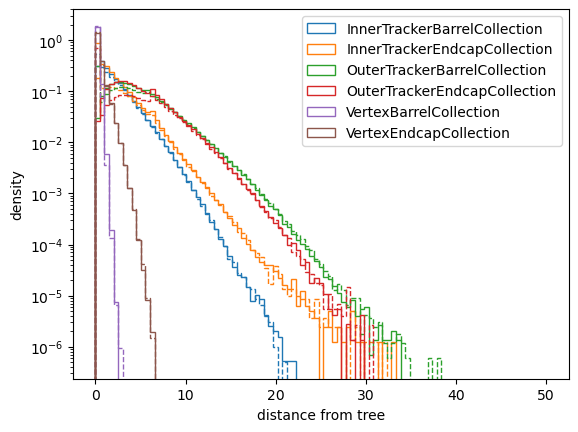

In [9]:



plt.figure()
for i, col in enumerate(collections):
    plt.hist(dists_truth[col], bins = np.linspace(0, 50, 100), histtype = "step", density = True, linestyle = "dashed", color = f"C{i}")
    plt.hist(dists_samples[col], bins = np.linspace(0, 50, 100), histtype = "step", density = True, color = f"C{i}", label = col)
plt.yscale("log")
plt.xlabel("distance from tree")
plt.ylabel("density")
plt.legend()
plt.show()

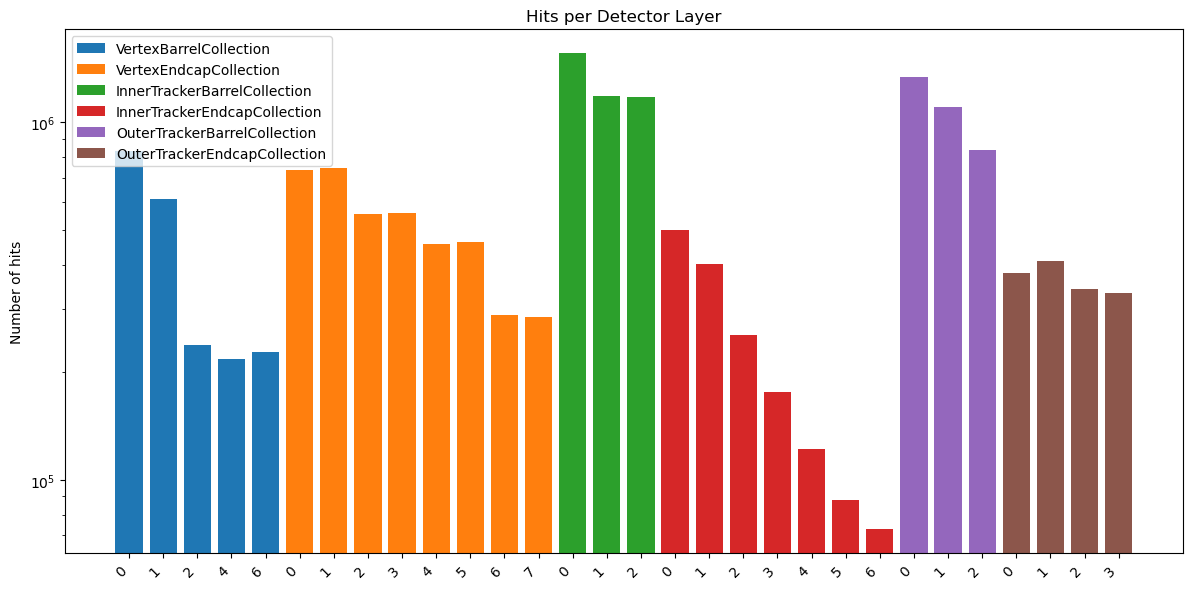

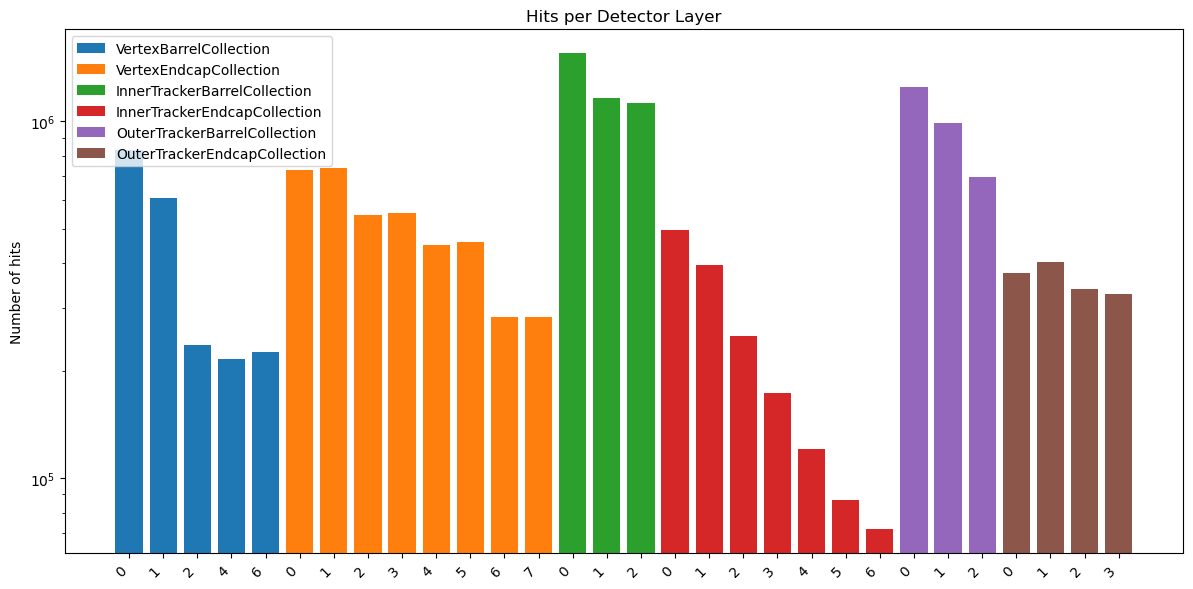

In [10]:
collections_order = [
    'VertexBarrelCollection',
    'VertexEndcapCollection',
    'InnerTrackerBarrelCollection',
    'InnerTrackerEndcapCollection',
    'OuterTrackerBarrelCollection',
    'OuterTrackerEndcapCollection'
]


def make_plot(col_hits_per_layer):
    
    # Prepare x positions
    width = 0.1  # width of each bar
    x_offsets = np.arange(0, len(col_hits_per_layer[collections_order[0]]))  # base positions for first collection
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Keep track of total x positions
    x_pos = 0
    x_labels = []
    x_ticks = []
    
    for coll in collections_order:
        layers = sorted(col_hits_per_layer[coll].keys())  # sort layers numerically
        counts = [col_hits_per_layer[coll][l] for l in layers]
    
        # compute positions for this collection
        positions = x_pos + np.arange(len(layers))
        ax.bar(positions, counts, width=0.8, label=coll)
        
        # collect labels and ticks
        x_labels.extend([f"{l}" for l in layers])
        x_ticks.extend(positions)
        
        # update x_pos for next collection to avoid overlap
        x_pos = positions[-1] + 1  # add gap between collections
    
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_ylabel("Number of hits")
    ax.set_title("Hits per Detector Layer")
    ax.legend()
    plt.tight_layout()
    plt.yscale("log")
    plt.savefig("figures/hits_per_detector_layer.png")
    plt.show()


make_plot(col_hits_per_layer_truth)
make_plot(col_hits_per_layer_samples)

In [13]:


for col in collections_order:

    print(col)
    #print(flow_samples_masked[col].shape)
    #print(cell_ids_samples[col].shape)


    loc = np.concatenate([flow_samples_masked[col], cell_ids_samples[col].reshape(-1,1)], axis = 1)

    
    print(loc.shape)

    n_samples = int(0.1 * len(loc))

    idx = np.random.choice(len(loc), size=n_samples, replace=False)

    loc_subset = loc[idx]

    print(loc_subset.shape)



    np.save(f"/pscratch/sd/r/rmastand/muon_collider/npys/flow_samples/{col}_shiyu.npy", loc_subset)
    #print(loc.shape,)

VertexBarrelCollection
(2115957, 10)
(211595, 10)
VertexEndcapCollection
(4041893, 10)
(404189, 10)
InnerTrackerBarrelCollection
(3836128, 10)
(383612, 10)
InnerTrackerEndcapCollection
(1593473, 10)
(159347, 10)
OuterTrackerBarrelCollection
(2938543, 10)
(293854, 10)
OuterTrackerEndcapCollection
(1446339, 10)
(144633, 10)


In [ ]:
data = []

collections_order = [
    'VertexBarrelCollection',
    'VertexEndcapCollection',
    'InnerTrackerBarrelCollection',
    'InnerTrackerEndcapCollection',
    'OuterTrackerBarrelCollection',
    'OuterTrackerEndcapCollection'
]


for col in collections_order:
    tmp = np.load(f"/pscratch/sd/r/rmastand/muon_collider/npys/flow_samples/{col}.npy")
    data.append(tmp)

    plt.figure()
    plt.hist(tmp[:,3], bins = 200)
    plt.title(col)
    plt.show()

data = np.concatenate(data)
print(data.shape)


In [ ]:
for i in range(data.shape[1]):
    plt.figure()
    plt.hist(data[:,i], bins = 100)
    plt.show()